# Saliency Map

In [ ]:
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

# Load pre-trained ResNet18
model = torchvision.models.resnet18(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import torch.nn.functional as F
test_dataset = torchvision.datasets.Flowers102(root='./data', split='test', download=True)
img_raw, label = test_dataset[11]
img = img_raw.convert('RGB')

preprocess = T.Compose([
    T.Resize((448, 448)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)
input_tensor.requires_grad = True

In [ ]:
output = model(input_tensor)
score, index = torch.max(output, 1)

model.zero_grad()
score.backward(retain_graph=True)

gradients = input_tensor.grad.data.abs().squeeze()
saliency, _ = torch.max(gradients, dim=0)

saliency = saliency.unsqueeze(0).unsqueeze(0)
smooth_saliency = F.avg_pool2d(saliency, kernel_size=7, stride=1, padding=3)
smooth_saliency = smooth_saliency.reshape(448, 448)

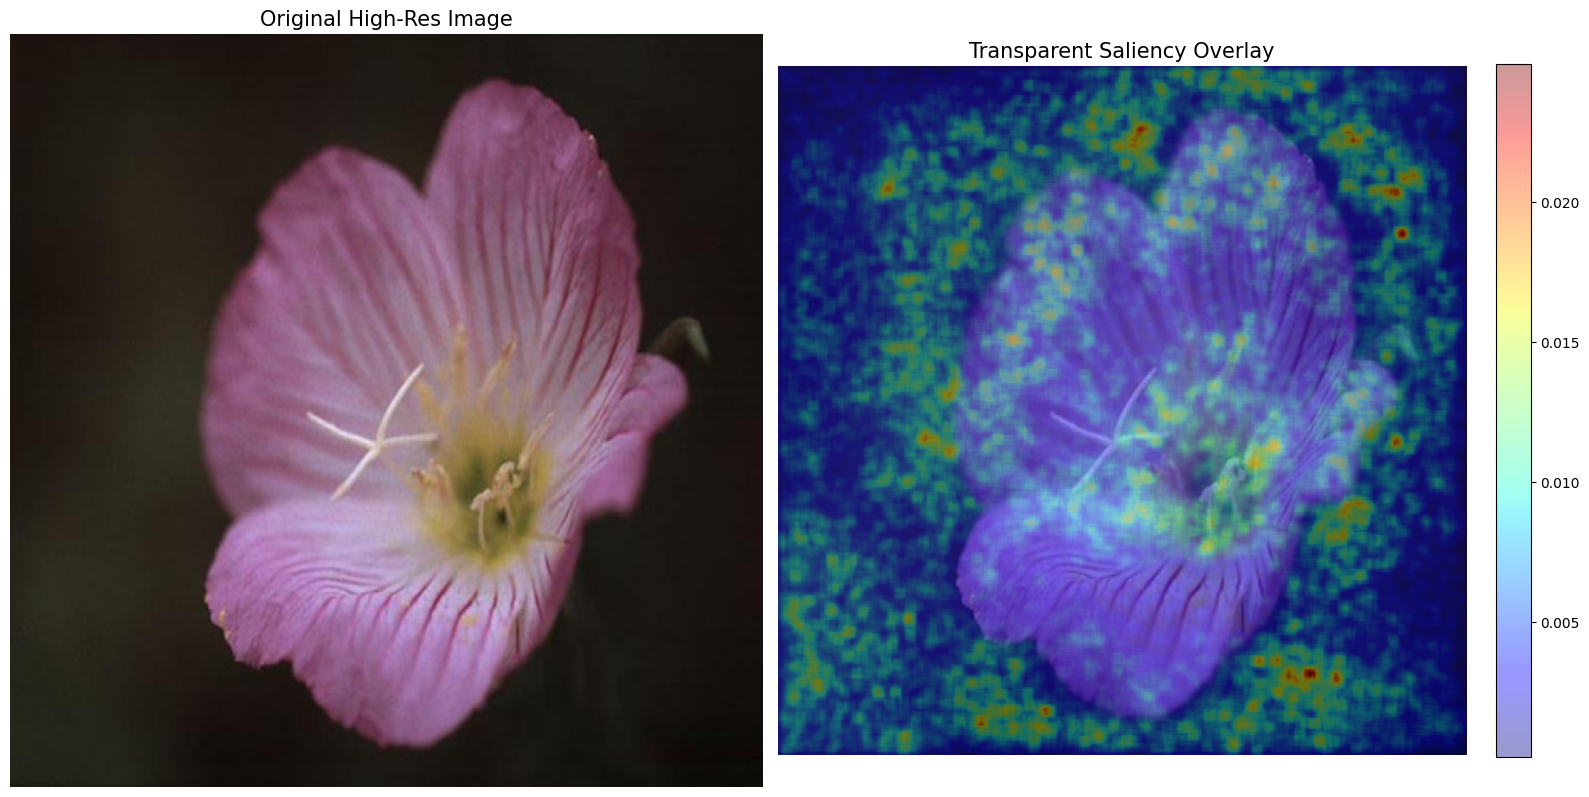

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(img.resize((448, 448)))
ax[0].set_title('Original High-Res Image', fontsize=15)
ax[0].axis('off')

ax[1].imshow(img.resize((448, 448)))
img_plot = ax[1].imshow(smooth_saliency.cpu(), cmap='jet', alpha=0.4)
ax[1].set_title('Transparent Saliency Overlay', fontsize=15)
ax[1].axis('off')

plt.colorbar(img_plot, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Integrated Gradients


In [ ]:
import torch.nn.functional as F

def integrated_gradients(model, input_tensor, target_class_idx, baseline=None, steps=50):
    if baseline is None:
        baseline = torch.zeros_like(input_tensor)

    input_diff = input_tensor - baseline
    gradients_along_path = []

    for i in range(steps):
        alpha = i / steps
        interpolated_input = (baseline + alpha * input_diff).clone().detach().requires_grad_(True)

        model.eval()
        output = model(interpolated_input)
        model.zero_grad()
        score = output[0, target_class_idx]
        score.backward(retain_graph=True)
        gradients_along_path.append(interpolated_input.grad.cpu().numpy())
    avg_grads = np.mean(gradients_along_path, axis=0)
    integrated_grad = input_diff.detach().cpu().numpy()

    return integrated_grad

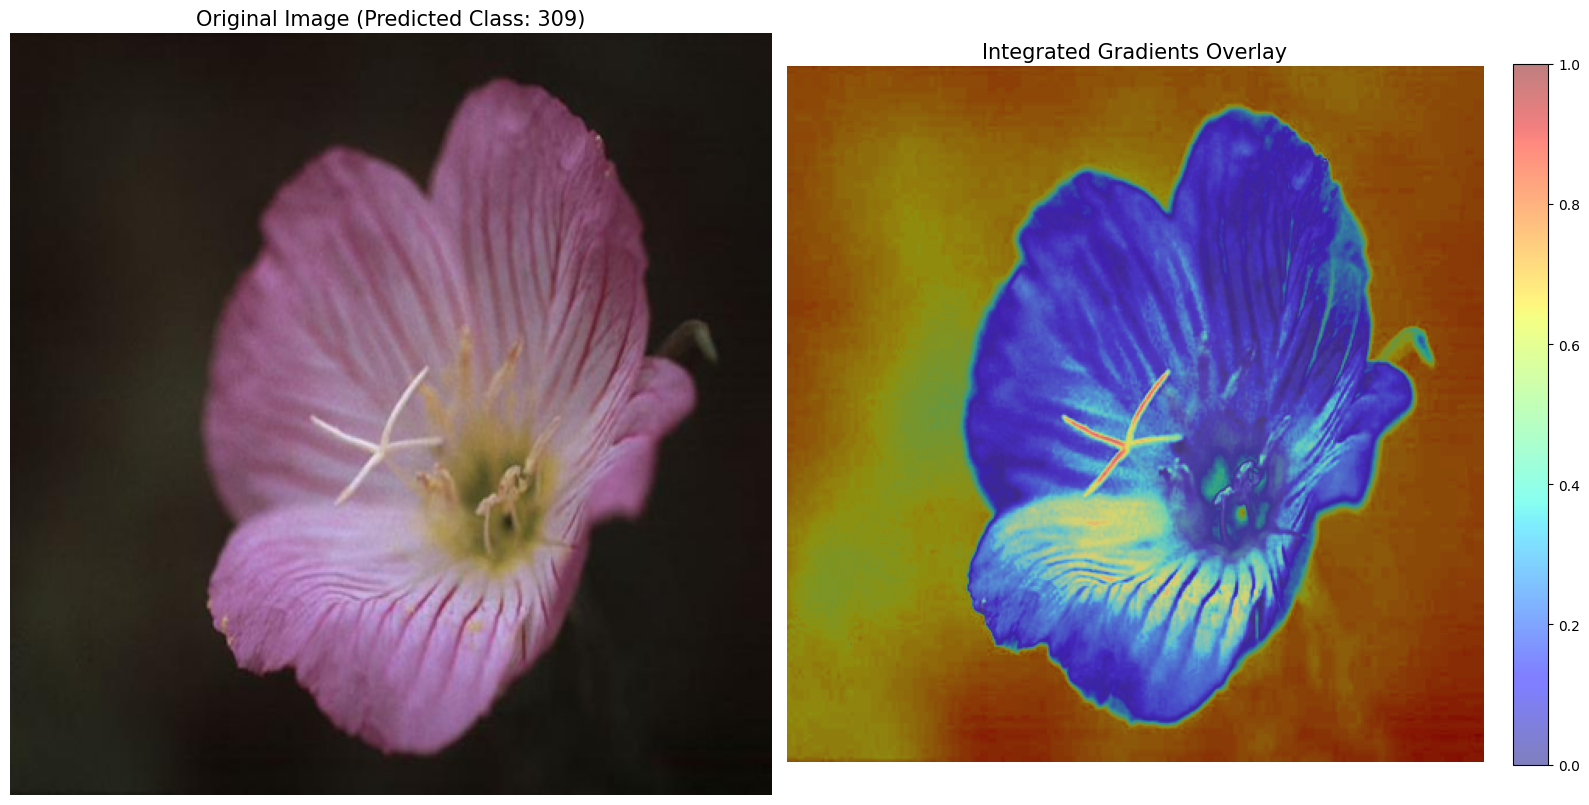

In [ ]:
probabilities = torch.nn.functional.softmax(output, dim=1)
predicted_class_idx = torch.argmax(probabilities).item()
integrated_grad_map = integrated_gradients(model, input_tensor, predicted_class_idx, steps=100)
integrated_grad_map_sum = np.sum(np.abs(integrated_grad_map.squeeze(0)), axis=0)
integrated_grad_map_sum = (integrated_grad_map_sum - integrated_grad_map_sum.min()) / (integrated_grad_map_sum.max() - integrated_grad_map_sum.min())

integrated_grad_map_resized = Image.fromarray(integrated_grad_map_sum * 255).resize((448, 448), Image.BILINEAR)
integrated_grad_map_resized = np.array(integrated_grad_map_resized) / 255.0

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img.resize((448, 448)))
ax[0].set_title(f'Original Image (Predicted Class: {predicted_class_idx})', fontsize=15)
ax[0].axis('off')

ax[1].imshow(img.resize((448, 448)))
img_plot = ax[1].imshow(integrated_grad_map_resized, cmap='jet', alpha=0.5)
ax[1].set_title('Integrated Gradients Overlay', fontsize=15)
ax[1].axis('off')

plt.colorbar(img_plot, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Grad-CAM (Gradient-weighted Class Activation Mapping)


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer = None
        self.gradients = None
        self.activations = None
        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def save_activation(module, input, output):
            self.activations = output

        for name, module in self.model.named_modules():
            if name == target_layer_name:
                self.target_layer = module
                self.target_layer.register_forward_hook(save_activation)
                self.target_layer.register_full_backward_hook(save_gradient)

        if self.target_layer is None:
            raise ValueError(f"Target layer '{target_layer_name}' not found in model.")

    def __call__(self, input_tensor, target_class=None):
        self.model.eval()

        self.model.zero_grad()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()
        output[:, target_class].backward(retain_graph=True)
        gradients = self.gradients
        activations = self.activations
        weights = torch.mean(gradients, dim=[0, 2, 3], keepdim=True)
        grad_cam_map = torch.sum(weights * activations, dim=1, keepdim=True)
        grad_cam_map = torch.relu(grad_cam_map)

        grad_cam_map = F.interpolate(grad_cam_map, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
        grad_cam_map = grad_cam_map.squeeze().cpu().detach().numpy()
        grad_cam_map = np.maximum(grad_cam_map, 0)
        grad_cam_map /= np.max(grad_cam_map)

        return grad_cam_map

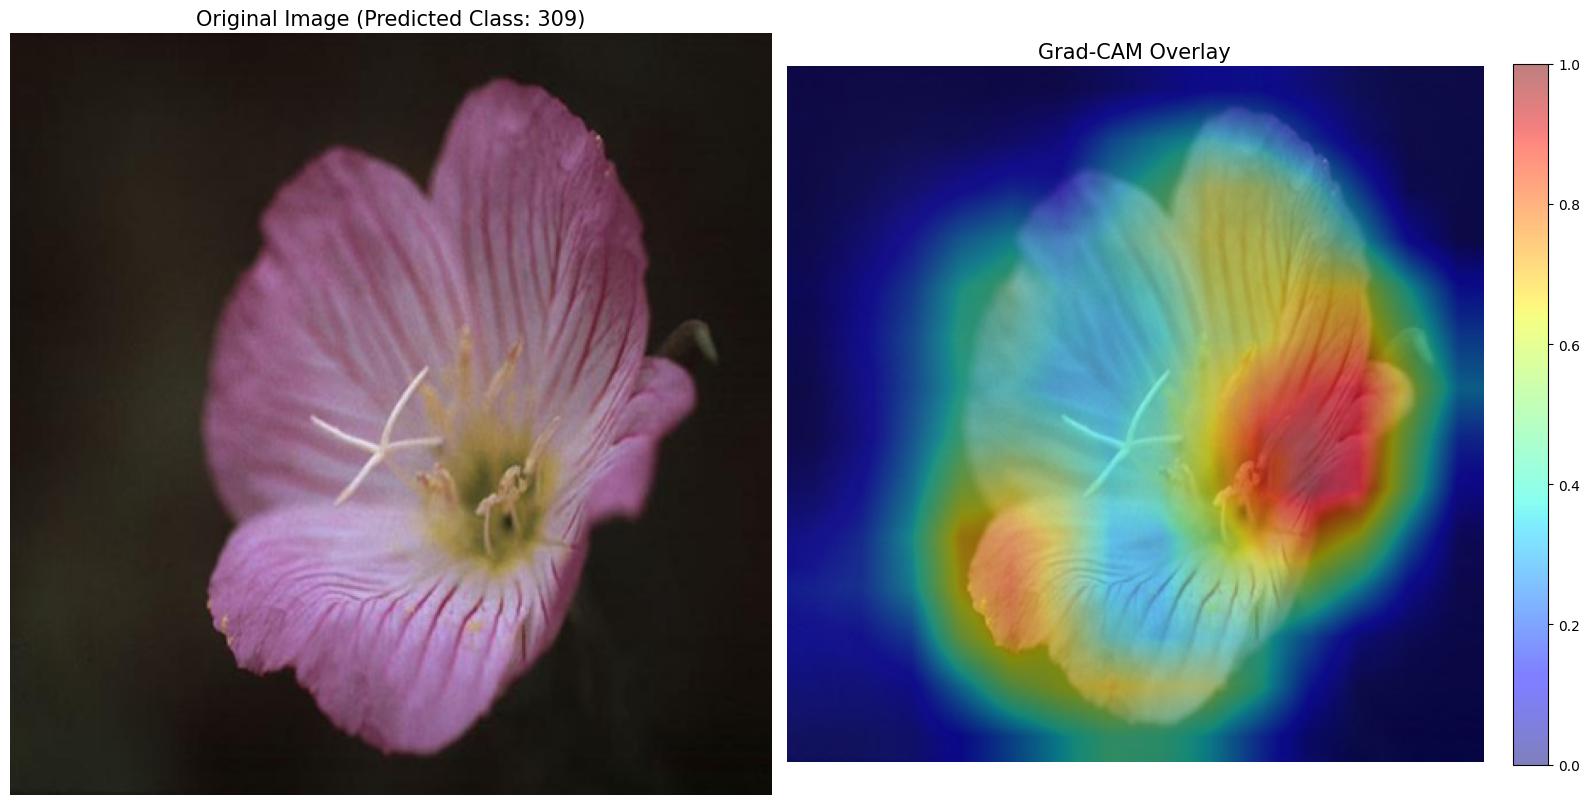

In [ ]:

gradcam_extractor = GradCAM(model, target_layer_name='layer4')

probabilities = torch.nn.functional.softmax(output, dim=1)
predicted_class_idx = torch.argmax(probabilities).item()

grad_cam_map = gradcam_extractor(input_tensor, target_class=predicted_class_idx)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(img.resize((448, 448)))
ax[0].set_title(f'Original Image (Predicted Class: {predicted_class_idx})', fontsize=15)
ax[0].axis('off')

ax[1].imshow(img.resize((448, 448)))
img_plot = ax[1].imshow(grad_cam_map, cmap='jet', alpha=0.5)
ax[1].set_title('Grad-CAM Overlay', fontsize=15)
ax[1].axis('off')

plt.colorbar(img_plot, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()